In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
# Complete Data
df=pd.read_csv('synthetic_credit_data_v2.csv')
df

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,BORR09996,36,Driver,25901.21,78,1,0.252,0,156,0,1
9996,BORR09997,43,Small Business Owner,63210.83,81,0,0.257,0,244,1,1
9997,BORR09998,59,Freelancer,45634.18,76,0,0.225,0,149,0,1
9998,BORR09999,29,Delivery Partner,24100.07,72,1,0.208,0,157,0,1


In [36]:
# Sample of data using the given function
df.head()

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0


In [37]:
# Some basic information using the function
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   borrower_id               10000 non-null  object 
 1   age                       10000 non-null  int64  
 2   occupation                10000 non-null  object 
 3   monthly_income            10000 non-null  float64
 4   income_consistency_score  10000 non-null  int64  
 5   utility_delay_days        10000 non-null  int64  
 6   debt_to_income_ratio      10000 non-null  float64
 7   active_loans              10000 non-null  int64  
 8   upi_transactions          10000 non-null  int64  
 9   previous_default          10000 non-null  int64  
 10  loan_status               10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [38]:
# Statistical information about the data
df.describe()

,age,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,40.399000,36978.500621,72.597700,1.983100,0.332028,0.868900,152.844700,0.14770,0.785500
std,11.511961,16635.934493,15.733519,2.554421,0.198705,0.993082,43.419437,0.35482,0.410496
min,21.000000,10410.770000,5.000000,0.000000,0.020000,0.000000,5.000000,0.00000,0.000000
25%,30.000000,23616.337500,66.000000,0.000000,0.209000,0.000000,124.000000,0.00000,1.000000
50%,40.000000,32420.130000,75.000000,1.000000,0.271000,1.000000,157.000000,0.00000,1.000000
75%,50.000000,49256.072500,83.000000,2.000000,0.357250,1.000000,183.000000,0.00000,1.000000
max,60.000000,86824.970000,100.000000,19.000000,0.980000,4.000000,296.000000,1.00000,1.000000


In [39]:
# Default(0) and Non-Default(1)
df['loan_status'].value_counts()

1    7855
0    2145
Name: loan_status, dtype: int64

In [40]:
# Default Rate(0) and Non-Default Rate(1)
df['loan_status'].value_counts(normalize=True)*100

1    78.55
0    21.45
Name: loan_status, dtype: float64

In [41]:
# Default by occupation
# Answer that which occupation defaults most among given set of occupations
# 0 represent default
# 1 represent repaid timely
occupation_default=pd.crosstab(
    df['occupation'],
    df['loan_status'],
    normalize='index')
occupation_default

loan_status,0,1
occupation,,
Delivery Partner,0.249480,0.750520
Driver,0.223606,0.776394
Freelancer,0.211656,0.788344
Kirana Owner,0.198304,0.801696
Small Business Owner,0.180268,0.819732


<function matplotlib.pyplot.show(close=None, block=None)>

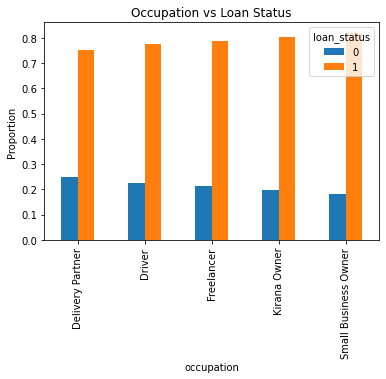

In [42]:
# Pictorial representation of occupation_default
# 0 represent default
# 1 represent repaid timely
occupation_default.plot(kind='bar')
plt.ylabel('Proportion')
plt.title('Occupation vs Loan Status')
plt.show

In [43]:
# Calculation of average debt to income ratio for defaulter and non defaulter
# Group 0- Borrowers who defaulted
# Group 1- Borrowers who repaid
df.groupby('loan_status')[
    'debt_to_income_ratio'].mean()

loan_status
0    0.583680
1    0.263308
Name: debt_to_income_ratio, dtype: float64

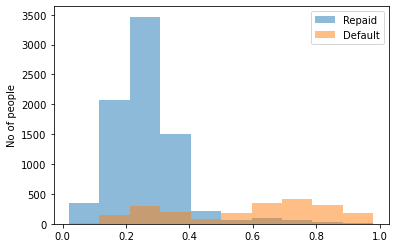

In [51]:
#Representation of both groups
plt.hist(df[df['loan_status']==1]['debt_to_income_ratio'],
         alpha=0.5,
         label='Repaid')
plt.hist(df[df['loan_status']==0]['debt_to_income_ratio'],
         alpha=0.5,
         label='Default')
plt.ylabel('No of people')
plt.legend()
plt.show()


In [52]:
# Calculation of average income consistency for defaulter and non-defaulter
# Group 0- Borrowers who defaulted
# Group 1- Borrowers who repaid
df.groupby('loan_status')[
    'income_consistency_score'].mean()

loan_status
0    55.815851
1    77.180395
Name: income_consistency_score, dtype: float64

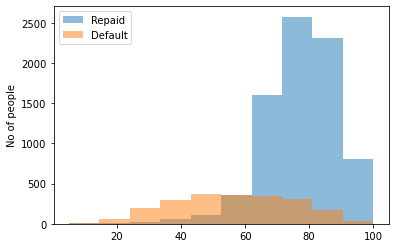

In [53]:
#Representation of both groups
plt.hist(
    df[df["loan_status"]==1]["income_consistency_score"],
    alpha=0.5,
    label="Repaid")
plt.hist(
    df[df["loan_status"]==0]["income_consistency_score"],
    alpha=0.5,
    label="Default")
plt.ylabel('No of people')
plt.legend()
plt.show()